# Example
This is the set up for how each part of this project will fit together as a whole. Ideally this will be lest of a testing ground and more of a demonstration of progress as the automation algorithm comes togetherr.

# Data Prep/ Zephyr Handeling
This section is intended to stand in as a placeholder for the rest of the Zephyr repository. I will do my best to keep it updated to Zephyr's code. Unfortunately, this function is not running in real time yet and is not being run on Zephyr hardware as a part of the Zepher repo. This section puts data into the format it would be in coming directly from zephyr.

Section heavily based on James Monico example

In [1]:
import glob # A common system tool for finding and parsing files 
data_dir = './rti_examples' # The name of the folder with the files 

In [2]:
import pickle # For loading files

file_name = 'RTI_Plane_2meteors.rti'#'RTI_Plane_2meteors.rti'#'RTI_faiding_plane_15s.rti'#'RTI_zephyrtx3_zephyrrx2_1678326201_15s.rti' #Example RTI data with single plane
with open(f'{data_dir}/{file_name}', "rb") as f:
        rti_xarray = pickle.load(f)

In [3]:
sample_time=int(rti_xarray.time[0])

In [4]:
import numpy as np 
import matplotlib.pyplot as plt # Plotting 
from matplotlib.ticker import MaxNLocator

# RTI diagram
rti_array = rti_xarray.values[:, 0, :250, :]
#fig, ax = plt.subplots(1, 1, figsize=(14, 7), layout='constrained')
rti_for_plot = np.abs(rti_array.mean(0))  # Collapse Doppler Dimension, mean across channels


(750000, 1)


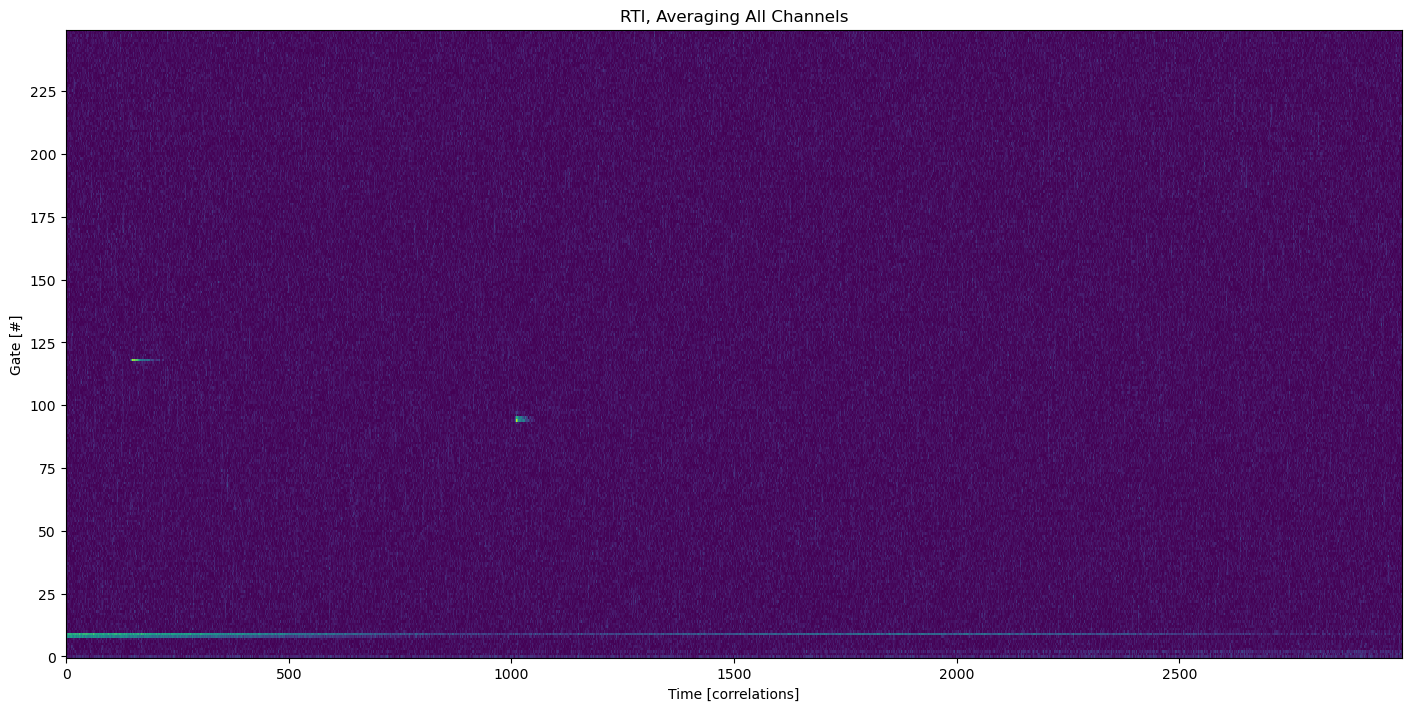

In [5]:
from sklearn.decomposition import PCA

# Performing PCA 
n_ch, n_gates, n_times = rti_array.shape
X = np.moveaxis(rti_array, 0, -1).reshape(-1, n_ch)
X = abs(X)
pca = PCA(n_components=1)
pca.fit(X)
rti_PCA = pca.fit_transform(X)
print(rti_PCA.shape)
rti_PCA = np.reshape(rti_PCA, (n_gates, n_times, 1)).squeeze()

# Plotting 
fig, ax = plt.subplots(1, 1, figsize=(14, 7), layout='constrained')
pca_for_plot = np.abs(rti_PCA[:, :])
ax.imshow(pca_for_plot, origin='lower', aspect='auto', interpolation='none', extent=None)
ax.set_xlabel('Time [correlations]')
ax.set_ylabel('Gate [#]')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title('RTI, Averaging All Channels')
plt.show()

In [6]:

def parse_selection(selection):
    """
    Parse selection for slices or ranges, with support for 'all' and specific indices or ranges.

    Parameters:
    - selection: Can be 'all', a string for channel names, or a list of indices.
    """
    # If selection is "all", return a slice that selects everything
    if isinstance(selection, str) and selection == "all":
        return slice(None)  # Select all elements
    
    # If selection is a string like "120:-1", handle as a slice
    elif isinstance(selection, str) and ":" in selection:
        try:
            return slice(*map(lambda x: int(x) if x.strip() else None, selection.split(":")))
        except ValueError as e:
            raise ValueError(f"Invalid slice string: '{selection}'. Error: {e}")
    
    # If selection is a list or array of values, return it as-is
    elif isinstance(selection, (list, np.ndarray)):
        return selection
    
    else:
        raise ValueError(f"Invalid selection format: '{selection}'.")

def reduce_xarray(xarray_in, dim_operations, value_agg_func=np.abs):
    """
    Reduces the RTI data based on the provided dimension operations (aggregation, selection).
    
    Parameters:
    - dim_operations (dict): Specifies "agg_func" and "selection" for each dimension.
        dim_operations = {
            "tx_rx_channel_pair": {"agg_func": None, "selection": "all"},  # Select polarimetric channels
            "doppler_hz": {"agg_func": None, "selection": [0]},  # Slice specific range
            "gate": {"agg_func": None, "selection": "all"},  # No aggregation
            "time": {"agg_func": None, "selection": "all"}  # Median over specific time slice
            }
    - value_agg_func (callable): Function to transform the data (e.g., np.abs, np.angle).
    
    Returns:
    - reduced_data (numpy.ndarray): Reduced data (2D or 3D) ready for plotting.
    """
    xarray_out = xarray_in.copy()
    xarray_out.attrs =  xarray_in.attrs.copy()
    
    # Apply operations for each dimension
    for dim, operations in dim_operations.items():
        if dim not in xarray_out.dims:
            raise ValueError(f"Dimension '{dim}' not found in data.")

        # Apply selection
        selection = operations.get("selection", "all")
        if dim == "tx_rx_channel_pair" and selection == "polarimetric":
            polarimetric_values = xarray_out.coords['polarimetric_channel'].values
            desired_channels = polarimetric_values[polarimetric_values != None]
            mask = np.isin(polarimetric_values, desired_channels)
            xarray_out = xarray_out.sel(tx_rx_channel_pair=mask)
        else:
            parsed_selection = parse_selection(selection)
            xarray_out = xarray_out.sel({dim: parsed_selection})

        # Apply aggregation if specified
        agg_func = operations.get("agg_func", None)
        if agg_func is not None:
            if not callable(agg_func):
                raise ValueError(f"Aggregation function for '{dim}' must be callable or None.")
            xarray_out = xarray_out.reduce(agg_func, dim=dim, keep_attrs=True)

    # Apply value aggregation function (e.g., np.abs, np.angle)
    if value_agg_func is not None:
        if not callable(value_agg_func):
            raise ValueError("value_agg_func must be a callable function.")
        xarray_out = value_agg_func(xarray_out)
    
    # Modify metadata attributes
    if value_agg_func is not None:
        if 'units' in xarray_out.attrs:
            xarray_out.attrs['units'] = f'{xarray_out.attrs["units"]} ({value_agg_func.__name__})'
        else:
            xarray_out.attrs['units'] = value_agg_func.__name__

    # Return reduced data (converted to numpy array)
    return np.squeeze(xarray_out)
            
'''
save_xarray_to_hdf5(cev_xarray, 'test3.cev')
cev_xarray_loaded = load_xarray_from_hdf5('test3.cev')
cev_xarray_loaded
'''


"\nsave_xarray_to_hdf5(cev_xarray, 'test3.cev')\ncev_xarray_loaded = load_xarray_from_hdf5('test3.cev')\ncev_xarray_loaded\n"

In [7]:
dim_operations = {
                    "tx_rx_channel_pair": {"agg_func": np.std, "selection": "all"},
                    "doppler_hz": {"agg_func": None, "selection": [0]}}
rti_for_det = reduce_xarray(rti_xarray, dim_operations, value_agg_func=np.abs) #Set up Data in the same format as in repository

# Plane Detection Algorithm

In [8]:
from Function_Storage.Plane_Detection import *
import pandas as pd

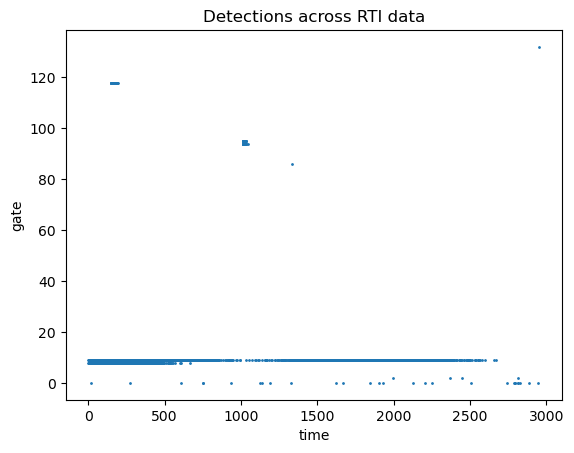

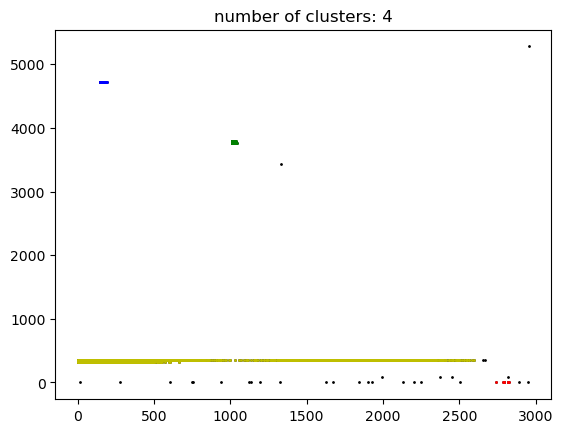

In [9]:
#Detect planes in RTI data
detections,img,ditc_proporties,peak_1D_idx=detect_plane(rti_for_det,0,{},['plot_detections','DBSCAN'])

In [10]:
# Print list of detections
ditc_proporties

[{'time': 1678336626},
 {'plane_number': 0,
  'max_time': np.int64(2597),
  'min_time': np.int64(1),
  'max_gate': np.float64(9.0),
  'min_gate': np.float64(8.0)},
 {'plane_number': 1,
  'max_time': np.int64(193),
  'min_time': np.int64(147),
  'max_gate': np.float64(118.0),
  'min_gate': np.float64(118.0)},
 {'plane_number': 2,
  'max_time': np.int64(1047),
  'min_time': np.int64(1010),
  'max_gate': np.float64(95.0),
  'min_gate': np.float64(94.0)},
 {'plane_number': 3,
  'max_time': np.int64(2828),
  'min_time': np.int64(2741),
  'max_gate': np.float64(0.0),
  'min_gate': np.float64(0.0)}]

In [11]:
detections_df = pd.DataFrame({'time_0': np.arange(0, 3001)})

In [12]:
#Create dataframe including detections found in RTI
for x in ditc_proporties[1:]:
    if x['max_time']-x['min_time']>300:
        #a_col_str=f"det{x['plane_number']}_a"
        #b_col_str=f"det{x['plane_number']}_b"
        avg_col_str=f"det{x['plane_number']}_avg"
        #avg_col_str=f"{x['plane_number']}"
        #detections_df[a_col_str]=x['max_gate']
        #detections_df[b_col_str]=x['min_gate']
        detections_df[avg_col_str]=(x['max_gate']+x['min_gate'])/2
detections_df

,time_0,det0_avg
0,0,8.5
1,1,8.5
2,2,8.5
3,3,8.5
4,4,8.5
...,...,...
2996,2996,8.5
2997,2997,8.5
2998,2998,8.5
2999,2999,8.5


# Retrive ADSB

In [13]:
import pyopensky
from pyopensky.config import opensky_config_dir

from pyopensky.trino import Trino
from pyopensky import trino
trino = pyopensky.trino.Trino()

In [14]:
import datetime

In [15]:
# retrive_ADSB function used to pull ADSB data from Opansky database
def retrive_ADSB(time, location):
    dt_object_initial = datetime.datetime.fromtimestamp(time, tz=datetime.timezone.utc)
    readable_time_initial = dt_object_initial.strftime("%Y-%m-%d %H:%M:%S UTC")

    dt_object_final = datetime.datetime.fromtimestamp(time+15, tz=datetime.timezone.utc)
    readable_time_final = dt_object_final.strftime("%Y-%m-%d %H:%M:%S UTC")

    flight_list_df = trino.history(
        start=dt_object_initial, 
        stop=dt_object_final, 
        bounds=location, #
        #airport="KDEN",
        cached=False
    )
    return flight_list_df

Next, the function aove will be used to find plane detections for the given time, over colorado. Note that during this step, data will be pulled from OpenSky, so an internet conection is crucual, and additionally, you will need to log into OpenSky in order to retrieve data. You may also need to wait for others using the database to finish, before you are able to pull the given data.

In [16]:
ADSB=retrive_ADSB(ditc_proporties[0]['time'],(-105,39.5,-104.6,40.25)) #very restrictive lat/lon

No credentials provided, falling back to browser authentication


Open the following URL in browser for the external authentication:
https://trino.opensky-network.org/oauth2/token/initiate/688590bb0d58b6e770682d329a5e68690acdcd29b5e23125055302852d0a8bc2


FINISHED: : 100% [00:00, 239%/s] 
DOWNLOAD: 112lines [00:00, 50.7klines/s]


In [17]:
#Print list of flights in given time and place
print(ADSB['callsign'].unique().tolist()) #List of available callsigns

['XOJ717', 'UPS805', 'FFT752', 'EVANS25', 'UPS895', 'EDG362', 'SWA270']


# Single Flight Tools

## Set up basic input to Single Flight Tools

In [18]:
# Function to sepperate data based on callsign, and remove planes under altitude
def sepperate_dataframe(df,altitude):
    df=df.dropna()
    dict={}
    for callsign in df.callsign.unique():
        querry_string=f'callsign=="{callsign}"'
        df=ADSB.query(querry_string)
        if max(df['geoaltitude'])>altitude:
         dict[callsign]=df
    return dict
        

In [19]:
planes=sepperate_dataframe(ADSB,1000)
callsigns=[*planes] #List all possible callsigns (* is called unpacking operator)

In [20]:
# Print list of flights with altitude sufficient to be off the runway
print(planes.keys())

dict_keys(['XOJ717', 'FFT752', 'UPS895', 'SWA270'])


In [21]:
from Function_Storage.Flight_Tools_class import *

In [22]:
import pandas as pd

In [23]:
#Set transmiter and reciever coordinates (May be slightly inacurate in example)
tx_latlonalt=[40.18265, -104.72611, 1.522]
rx_latlonalt=[39.53233, -104.59324, 1.888]



## use of Single Flight Tools

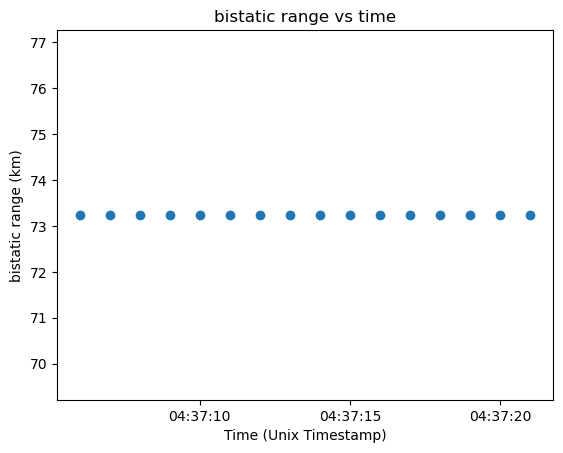

In [24]:
# Use of Single Flight Tools for single optimal plane
plane1=Data_Package(planes[callsigns[3]],tx_latlonalt,rx_latlonalt) #Will need to create function for more than one plane
plane1.name_thing()
plane1.convertCoords()
plane1.bistaticrange(True)

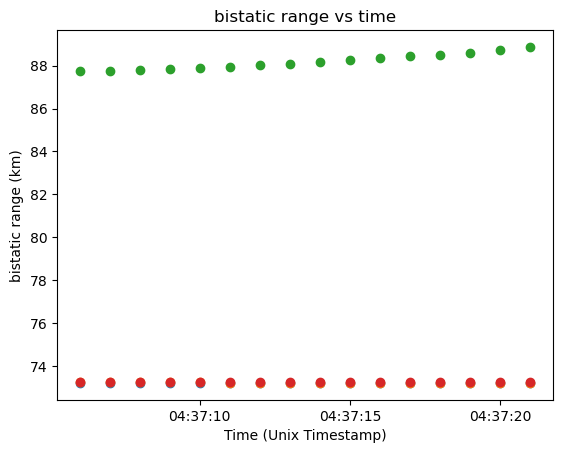

In [25]:
# Use Single Flight Tools to calculate the bystatic range, for non-runway planes
i=0
planes_to_interp={}  # [0]*len(planes)
while i< len(planes):
    plane=Data_Package(planes[callsigns[i]],tx_latlonalt,rx_latlonalt) #Will need to create function for more than one plane
    plane.name_thing()
    plane.convertCoords()
    plane.bistaticrange(True)
    plane.df["gate"]=plane.df["brange"]/15
    planes_to_interp[callsigns[i]]=plane
    i+=1
    

# Interpolation

Now that the Bistatic range and gate are known for each plane, we must interpolate the predicted values for all of the time values given in the RTI.

In [26]:
interp_df=planes_to_interp[callsigns[0]].df[['time','gate']]
cs=f"{callsigns[0]}"
interp_df.rename(columns={'gate': cs}, inplace=True)
i=1
while i<len(planes):
    cs=f"{callsigns[i]}"
    new_df=planes_to_interp[callsigns[i]].df[['time','gate']]
    new_df.rename(columns={'gate': cs}, inplace=True)
    interp_df=pd.merge(interp_df,new_df,on='time', how='outer')
    i+=1
interp_df

,time,XOJ717,FFT752,UPS895,SWA270
0,2023-03-09 04:37:06+00:00,4.881128,4.883218,5.848655,4.882726
1,2023-03-09 04:37:07+00:00,4.881128,4.883218,5.851352,4.882726
2,2023-03-09 04:37:08+00:00,4.881128,4.883218,5.853608,4.882726
3,2023-03-09 04:37:09+00:00,4.881128,4.882564,5.856713,4.882726
4,2023-03-09 04:37:10+00:00,4.881128,4.882564,5.860222,4.882726
5,2023-03-09 04:37:11+00:00,4.881128,4.882382,5.863713,4.882726
6,2023-03-09 04:37:12+00:00,4.881128,4.882382,5.867817,4.882726
7,2023-03-09 04:37:13+00:00,4.881128,4.882382,5.872535,4.882726
8,2023-03-09 04:37:14+00:00,4.881128,4.882382,5.87713,4.882726
9,2023-03-09 04:37:15+00:00,4.881128,4.882382,5.884356,4.882726


In [27]:

i=interp_df.index.min()
while i<= interp_df.index.max():
    time=interp_df['time'][i]
    epoch_time=time.timestamp()

    interp_df.loc[i,'epoch_time']=epoch_time
    i+=1
interp_df

,time,XOJ717,FFT752,UPS895,SWA270,epoch_time
0,2023-03-09 04:37:06+00:00,4.881128,4.883218,5.848655,4.882726,1.678337e+09
1,2023-03-09 04:37:07+00:00,4.881128,4.883218,5.851352,4.882726,1.678337e+09
2,2023-03-09 04:37:08+00:00,4.881128,4.883218,5.853608,4.882726,1.678337e+09
3,2023-03-09 04:37:09+00:00,4.881128,4.882564,5.856713,4.882726,1.678337e+09
4,2023-03-09 04:37:10+00:00,4.881128,4.882564,5.860222,4.882726,1.678337e+09
5,2023-03-09 04:37:11+00:00,4.881128,4.882382,5.863713,4.882726,1.678337e+09
6,2023-03-09 04:37:12+00:00,4.881128,4.882382,5.867817,4.882726,1.678337e+09
7,2023-03-09 04:37:13+00:00,4.881128,4.882382,5.872535,4.882726,1.678337e+09
8,2023-03-09 04:37:14+00:00,4.881128,4.882382,5.87713,4.882726,1.678337e+09
9,2023-03-09 04:37:15+00:00,4.881128,4.882382,5.884356,4.882726,1.678337e+09


In [28]:
# Points to interpolate on (array?)
xi=rti_xarray.time.values

x=np.array(interp_df['epoch_time']) #x coordinates (time as epoch time)
y=np.array(interp_df['XOJ717']) #y coordinates (gate)
y

array([4.88112768, 4.88112768, 4.88112768, 4.88112768, 4.88112768,
       4.88112768, 4.88112768, 4.88112768, 4.88112768, 4.88112768,
       4.88112768, 4.88112768, 4.88112768, 4.88112768, 4.88112768,
       4.88112768])

In [29]:
import numpy as np
from scipy.interpolate import BarycentricInterpolator #TODO: make sure scipy is included in essential libraries

# x and y defined

poly=BarycentricInterpolator(interp_df['epoch_time'].values, interp_df[callsigns].values)

#Interpolate data for use in point pairing
pairing_df=pd.DataFrame({'time': xi})
i=0
while i<len(pairing_df):
    y_new = poly(xi)
    i+=1
    
pairing_df[callsigns]=y_new
pairing_df

,time,XOJ717,FFT752,UPS895,SWA270
0,1.678337e+09,4.881128,4.883218,5.848655,4.882726
1,1.678337e+09,4.881128,4.882859,5.854146,4.882726
2,1.678337e+09,4.881128,4.882511,5.859462,4.882726
3,1.678337e+09,4.881128,4.882174,5.864606,4.882726
4,1.678337e+09,4.881128,4.881847,5.869583,4.882726
...,...,...,...,...,...
2995,1.678337e+09,4.881128,4.882851,5.884171,4.882726
2996,1.678337e+09,4.881128,4.882655,5.891754,4.882726
2997,1.678337e+09,4.881128,4.882453,5.899588,4.882726
2998,1.678337e+09,4.881128,4.882243,5.907678,4.882726


In [30]:
pairing_df=pairing_df.join(detections_df, how='left') #Only run once, it will get confused if run a second time
pairing_df=pairing_df.drop('time_0',axis=1)
pairing_df

,time,XOJ717,FFT752,UPS895,SWA270,det0_avg
0,1.678337e+09,4.881128,4.883218,5.848655,4.882726,8.5
1,1.678337e+09,4.881128,4.882859,5.854146,4.882726,8.5
2,1.678337e+09,4.881128,4.882511,5.859462,4.882726,8.5
3,1.678337e+09,4.881128,4.882174,5.864606,4.882726,8.5
4,1.678337e+09,4.881128,4.881847,5.869583,4.882726,8.5
...,...,...,...,...,...,...
2995,1.678337e+09,4.881128,4.882851,5.884171,4.882726,8.5
2996,1.678337e+09,4.881128,4.882655,5.891754,4.882726,8.5
2997,1.678337e+09,4.881128,4.882453,5.899588,4.882726,8.5
2998,1.678337e+09,4.881128,4.882243,5.907678,4.882726,8.5


In [31]:
#Function defenition for Adjusted norm
def adjusted_norm(dataframe):#Should workshop the name
    
    threshold = .1 # The Largest norm which will still be accepted as a correct value
    plane_num = 0
    norm_list=['time','ADSB_plane']

    while plane_num <= dataframe.shape[1]-3:
        plane=f"det{plane_num}_avg"
        norm=np.linalg.norm(dataframe['gate']-dataframe[plane])/len(dataframe)
        norm_list.append(norm)
        plane_num +=1
    matched_norm=min(norm_list[2:])

    if matched_norm > threshold:
        return "None",norm_list
    
    matched_col=f"det{norm_list.index(matched_norm)-2}_avg"
    return matched_col, norm_list


In [32]:
# Use adjusted norm value to calculate adjusted norm.
paring=adjusted_norm(pairing_df)
paring

KeyError: 'gate'

Root mean error
also report Root error, don't square, average positive/negative, if it is not zero you have a bias, help determine time error.

Yaml config files: for tx. rx